In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

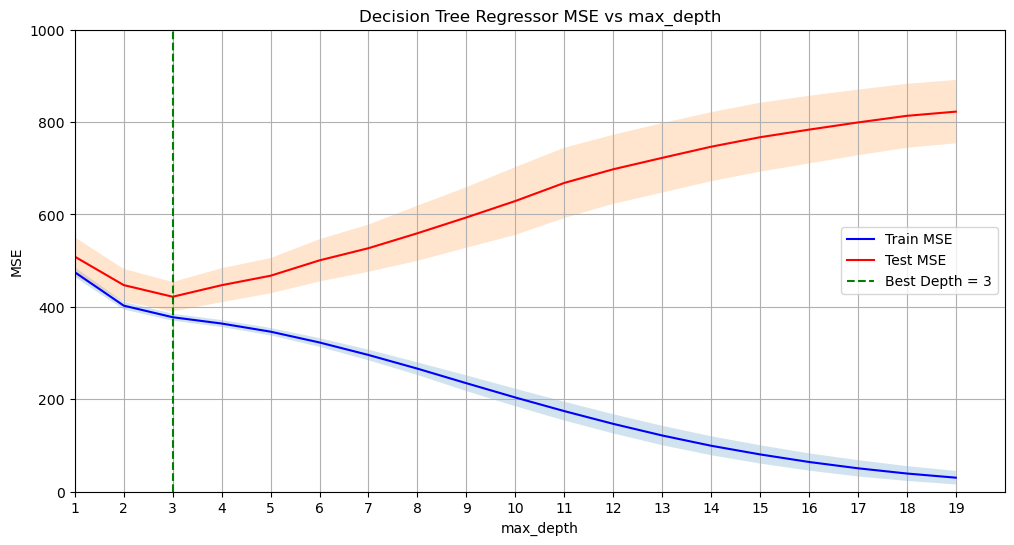

In [5]:
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generate data
X, y = make_regression(n_samples=1000, n_features=1, noise=20, random_state=42)


# Fit regression model for different depths and plot train and test mse
train_mse = []
test_mse = []
train_std = []
test_std = []
max_depths = 20
for depth in range(1, max_depths):
    train_results = []
    test_results = []
    for iteation in range(100):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=iteation)
        model = DecisionTreeRegressor(max_depth=depth)
        model.fit(X_train, y_train)
        train_results.append(mean_squared_error(y_train, model.predict(X_train)))
        test_results.append(mean_squared_error(y_test, model.predict(X_test)))
    train_mse.append(np.mean(train_results))
    test_mse.append(np.mean(test_results))
    train_std.append(np.std(train_results))
    test_std.append(np.std(test_results))

# Plot mse vs max_depth for train and test sets with std deviation, extract the best depth 
plt.figure(figsize=(12, 6))
plt.plot(range(1, max_depths), train_mse, 'b', label='Train MSE')
plt.plot(range(1, max_depths), test_mse, 'r', label='Test MSE')
plt.fill_between(range(1, max_depths), np.array(train_mse) - np.array(train_std), np.array(train_mse) + np.array(train_std), alpha=0.2)
plt.fill_between(range(1, max_depths), np.array(test_mse) - np.array(test_std), np.array(test_mse) + np.array(test_std), alpha=0.2)


best_depth = np.argmin(test_mse) + 1
plt.axvline(x=best_depth, color='g', linestyle='--', label='Best Depth = {}'.format(best_depth))
plt.title('Decision Tree Regressor MSE vs max_depth')
plt.ylim(0, 1000)
plt.xlim(1, max_depths)
plt.xticks(range(1, max_depths))
plt.grid()
plt.xlabel('max_depth') 
plt.ylabel('MSE')
plt.legend(loc='best')
plt.show()